In [33]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [34]:
from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, TNG_H

In [35]:
# hydro
subhalo_ids = []
stellar_mass = []
subhalo_mass_hydro = []

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass_hydro.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass = convert_tng_mass(np.array(subhalo_mass_hydro)) # log10(Msun / h)
stellar_mass = convert_tng_mass(np.array(stellar_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 448/448 [00:06<00:00, 66.54it/s] 
/Users/imendoza/code/multicam-tng-mah/multicam_tng/utils.py:35: RuntimeWarning: divide by zero encountered in log10
  return np.where(gmass > 0, np.log10(gmass * 1e10 / TNG_H), 0)


In [36]:
smass = stellar_mass[stellar_mass > np.log10(1.4e6 * 100 / TNG_H)]

(array([1.2658e+04, 9.7240e+03, 6.9040e+03, 4.3830e+03, 3.0300e+03,
        2.0860e+03, 6.7700e+02, 1.8500e+02, 5.5000e+01, 9.0000e+00]),
 array([ 8.31530857,  8.72213364,  9.1289587 ,  9.53578377,  9.94260883,
        10.3494339 , 10.75625896, 11.16308403, 11.5699091 , 11.97673416,
        12.38355923]),
 <BarContainer object of 10 artists>)

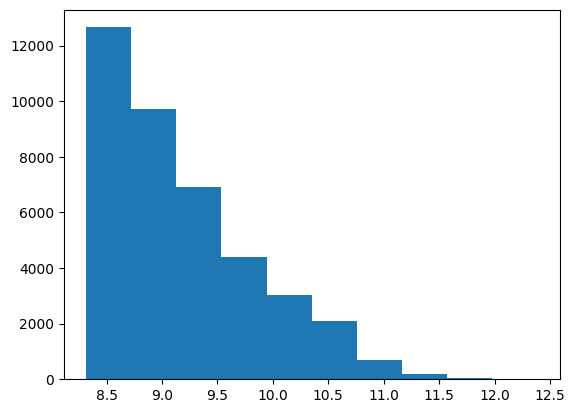

In [37]:
plt.hist(smass)

In [38]:
# # stellar mass function 
# x1 = 8.3
# x2 = 11.5
# bins = np.linspace(x1, x2, 1001)
# nh = np.array([sum(smass > b) for b in bins])
# smf = nh /  len(smass) / 100 # box
# smf /= smf.sum()

# plt.semilogy(bins, smf)
# # plt.yscale('log')

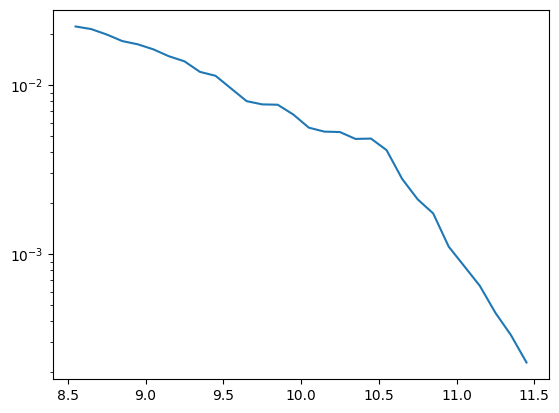

In [39]:
# stellar mass function 
x1 = 8.5
x2 = 11.6
delta = 0.1
bins = np.arange(x1, x2, step=delta)
V_box = 110.7**3


nd = []
for ii in range(len(bins) - 1):
    b1 = bins[ii]
    b2 = bins[ii+1]
    cond1 = smass > b1 
    cond2 = smass < b2
    number_density = sum(cond1 & cond2) / V_box / delta # box volume
    nd.append(number_density)

smf = np.array(nd)
x = (bins[1:] + bins[:-1]) /2

plt.semilogy(x, smf)
# plt.yscale('log')


In [40]:
lf = np.vstack([x, smf]).T
lf.shape

(30, 2)

In [41]:
lf[:, 0], lf[:, 1]

(array([ 8.55,  8.65,  8.75,  8.85,  8.95,  9.05,  9.15,  9.25,  9.35,
         9.45,  9.55,  9.65,  9.75,  9.85,  9.95, 10.05, 10.15, 10.25,
        10.35, 10.45, 10.55, 10.65, 10.75, 10.85, 10.95, 11.05, 11.15,
        11.25, 11.35, 11.45]),
 array([0.02218828, 0.02142164, 0.01989574, 0.01819292, 0.01740416,
        0.0162542 , 0.01479464, 0.01380686, 0.01195661, 0.0113374 ,
        0.00953875, 0.00802759, 0.00768113, 0.00764427, 0.00669334,
        0.00559498, 0.00530012, 0.00527064, 0.00479886, 0.00482098,
        0.00412068, 0.00278644, 0.00210826, 0.00173968, 0.00110573,
        0.00084772, 0.00064869, 0.00044966, 0.00033172, 0.00022852]))

# Yao's code

In [42]:
import matplotlib.pyplot as plt
from AbundanceMatching import AbundanceFunction, LF_SCATTER_MULT, calc_number_densities, add_scatter, rematch


In [43]:
af = AbundanceFunction(lf[:,0], lf[:,1], ext_range=(x1, x2), 
                       faint_end_first=True, bright_end_fit_points=10)

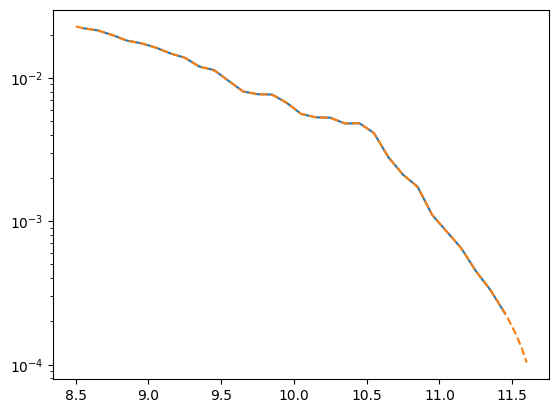

In [44]:
# check the abundance function
plt.semilogy(lf[:,0], lf[:,1])


_x = np.linspace(x1, x2, 101)
plt.semilogy(_x, af(_x), ls='--', ) # fit

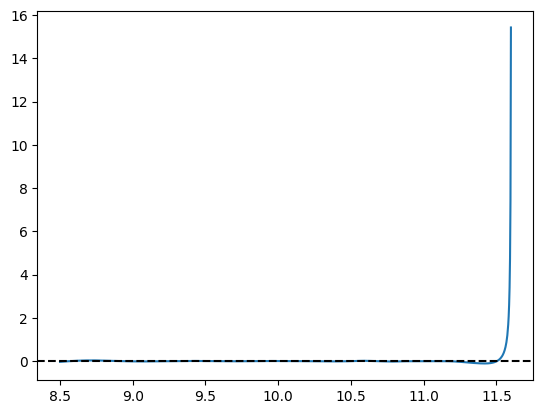

In [45]:
# deconvolution and check results (it's a good idea to always check this)
scatter = 0.2
remainder = af.deconvolute(scatter, repeat=20)
_x, nd = af.get_number_density_table()
plt.plot(_x, remainder/nd);
# plt.axhline(1.0)
plt.axhline(0.0, ls='--', c='k')

In [46]:
# get haloes
_file = "../../data/tng100_trees.npz"
with open(_file, 'rb') as fp:
    trees_data = np.load(fp)
    matches = trees_data['matches']
    bdmo = trees_data['bdmo']
    tdmo = trees_data['tdmo']
    bbar = trees_data['bbar']
    tbar = trees_data['tbar']
    
mask2 = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])
vpeak = np.log10(bdmo['vpeak'][mask2])
vpeak.shape

(533674,)

In [47]:
# get number densities of the halo catalog
box_size = 110.7
nd_halos = calc_number_densities(vpeak, box_size)

In [48]:
catalog = af.match(nd_halos)

In [49]:
catalog_sc = af.match(nd_halos, scatter)

In [50]:
np.isnan(catalog).sum(), np.isnan(catalog_sc).sum(), catalog.shape - np.isnan(catalog).sum(), catalog_sc.shape - np.isnan(catalog_sc).sum()

(np.int64(500167), np.int64(500167), array([33507]), array([33507]))

(array([0.89329762, 0.81845158, 0.73895295, 0.6762441 , 0.58784486,
        0.51967427, 0.44058021, 0.35218097, 0.31718539, 0.28664011,
        0.23667532, 0.20896206, 0.19884773, 0.18549681, 0.12056281,
        0.07970092, 0.04935793, 0.03094985, 0.02083552, 0.01193491,
        0.00890061]),
 array([ 8.50001293,  8.64743431,  8.79485569,  8.94227707,  9.08969846,
         9.23711984,  9.38454122,  9.5319626 ,  9.67938398,  9.82680537,
         9.97422675, 10.12164813, 10.26906951, 10.4164909 , 10.56391228,
        10.71133366, 10.85875504, 11.00617642, 11.15359781, 11.30101919,
        11.44844057, 11.59586195]),
 [<matplotlib.patches.Polygon at 0x12aa78550>])

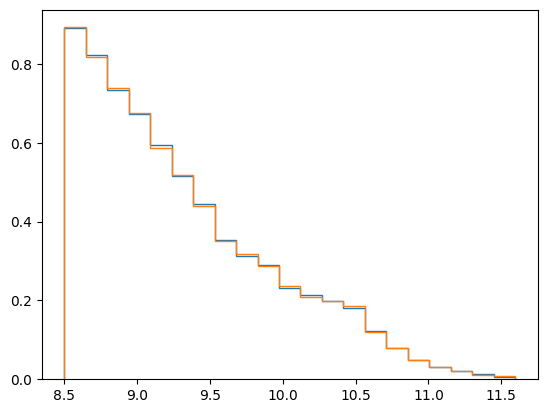

In [51]:
mask = ~np.isnan(catalog)

mask_ = (smass > x1) & ( smass < x2)
_, bins, _ = plt.hist(catalog[mask], bins=21, histtype='step', density=True)
plt.hist(smass[mask_], bins=bins, density=True, histtype='step')


(array([0.89329762, 0.81845158, 0.73895295, 0.6762441 , 0.58784486,
        0.51967427, 0.44058021, 0.35218097, 0.31718539, 0.28664011,
        0.23667532, 0.20896206, 0.19884773, 0.18549681, 0.12056281,
        0.07970092, 0.04935793, 0.03094985, 0.02083552, 0.01193491,
        0.00890061]),
 array([ 8.50001293,  8.64743431,  8.79485569,  8.94227707,  9.08969846,
         9.23711984,  9.38454122,  9.5319626 ,  9.67938398,  9.82680537,
         9.97422675, 10.12164813, 10.26906951, 10.4164909 , 10.56391228,
        10.71133366, 10.85875504, 11.00617642, 11.15359781, 11.30101919,
        11.44844057, 11.59586195]),
 [<matplotlib.patches.Polygon at 0x12663dd10>])

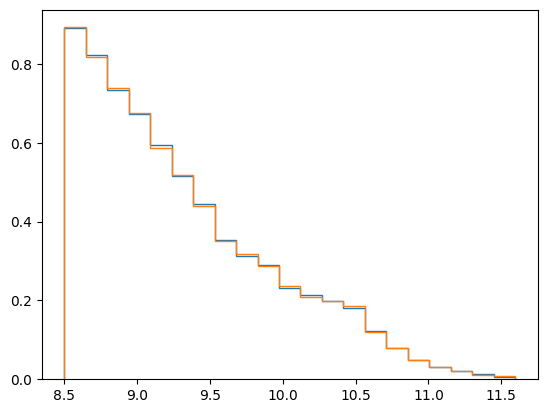

In [52]:
mask = ~np.isnan(catalog_sc)

mask_ = (smass > x1) & ( smass < x2)
_, bins, _ = plt.hist(catalog_sc[mask], bins=21, histtype='step', density=True)
plt.hist(smass[mask_], bins=bins, density=True, histtype='step')


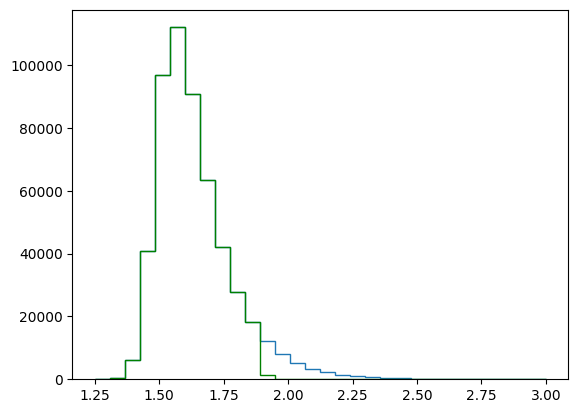

In [53]:
#  histogram of nan's

bins = np.linspace(1.25, 3.0, 31)
plt.hist(vpeak, bins=bins,histtype='step');



mask = np.isnan(catalog_sc)
plt.hist(vpeak[mask], bins=bins,histtype='step', color='g');

# assumes there are monotonically related and does abundance matching only on the top ones 

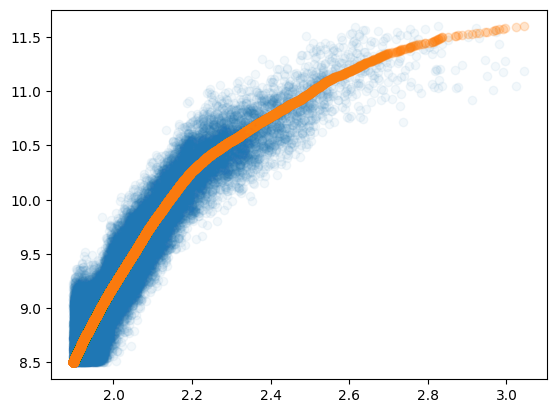

In [54]:
# stellar mass function 
mask = ~np.isnan(catalog)

plt.scatter(vpeak[mask], catalog_sc[mask], alpha=0.05)
plt.scatter(vpeak[mask], catalog[mask], alpha=0.2)

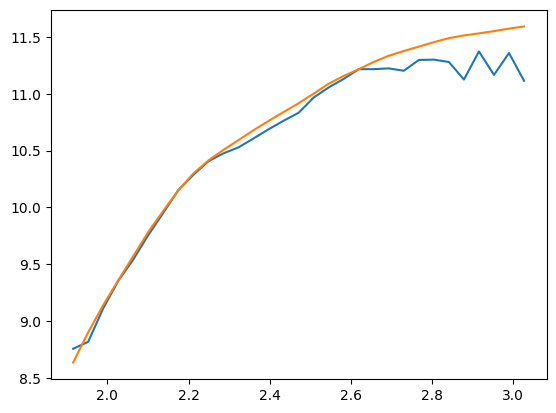

In [ ]:
# compare mean relations
from scipy.stats import binned_statistic

sc_sham_mean, bin_edges, _ = binned_statistic(vpeak[mask], catalog_sc[mask], bins=31, statistic='mean')

sham_mean, bin_edges, _ = binned_statistic(vpeak[mask], catalog[mask], bins=31, statistic='mean')


mids = (bin_edges[:-1]+ bin_edges[1:]) / 2



plt.plot(mids, sc_sham_mean)
plt.plot(mids, sham_mean)